In [3]:
# ============================================================
# FOOTBALL CV - DETECÇÃO E TRACKING COM YOLOv8
# Projeto TCC - Pós-Graduação em Visão Computacional
# ============================================================
# Autor: [Seu Nome]
# Data: 2024
# Dataset: SoccerTrack v2 (em breve) / Vídeo Sintético (teste)
# ============================================================


# SEÇÃO 1: SETUP E INSTALAÇÃO

In [1]:
print("🚀 Configurando ambiente...")

# Instalar dependências
!pip install ultralytics opencv-python matplotlib seaborn plotly --quiet

# Verificar GPU
import torch
if torch.cuda.is_available():
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"   Memória: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ GPU não detectada. Usando CPU (mais lento)")

🚀 Configurando ambiente...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.4 MB/s eta 0:00:00
✅ GPU detectada: Tesla T4
   Memória: 15.64 GB


# SEÇÃO 2: IMPORTAÇÃO DE BIBLIOTECAS


In [2]:

print("\n📚 Importando bibliotecas...")

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from datetime import datetime
import os

# Configurar matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas carregadas!")


📚 Importando bibliotecas...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Bibliotecas carregadas!


# SEÇÃO 3: CRIAÇÃO DE VÍDEO SINTÉTICO

In [4]:
print("\n🎬 Criando vídeo sintético para testes...")

def create_synthetic_video(output_path="data/raw/test_football.mp4",
                           duration_sec=10,
                           fps=30):
    """
    Cria vídeo sintético simulando partida de futebol
    com jogadores (círculos azuis/vermelhos) e bola (branca)
    """
    Path("data/raw").mkdir(parents=True, exist_ok=True)

    width, height = 640, 480
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print(f"  📹 Resolução: {width}x{height}")
    print(f"  ⏱️ Duração: {duration_sec}s")
    print(f"  🎞️ Frames: {fps * duration_sec}")

    # Posições iniciais aleatórias (reprodutíveis)
    np.random.seed(42)
    # Definindo explicitamente como float64 para permitir somas decimais sem erro de cast
    team_a_pos = (np.random.rand(6, 2) * [width, height//2]).astype(np.float64)
    team_b_pos = (np.random.rand(6, 2) * [width, height//2] + [0, height//2]).astype(np.float64)
    ball_pos = np.array([width//2, height//2], dtype=np.float64)

    total_frames = fps * duration_sec

    for frame in range(total_frames):
        # Fundo verde (gramado)
        img = np.zeros((height, width, 3), dtype=np.uint8)
        img[:] = (34, 139, 34)  # Forest Green

        # Desenhar campo
        cv2.line(img, (0, height//2), (width, height//2), (255, 255, 255), 2)
        cv2.circle(img, (width//2, height//2), 50, (255, 255, 255), 2)
        cv2.rectangle(img, (0, 0), (50, height), (255, 255, 255), 2)
        cv2.rectangle(img, (width-50, 0), (width, height), (255, 255, 255), 2)

        # Movimento aleatório suave
        team_a_pos += np.random.randn(6, 2) * 3
        team_b_pos += np.random.randn(6, 2) * 3
        ball_pos += np.random.randn(2) * 5

        # Manter dentro dos limites
        team_a_pos = np.clip(team_a_pos, [20, 20], [width-20, height//2-20])
        team_b_pos = np.clip(team_b_pos, [20, height//2+20], [width-20, height-20])
        ball_pos = np.clip(ball_pos, [20, 20], [width-20, height-20])

        # Time A (azul)
        for pos in team_a_pos:
            cv2.circle(img, (int(pos[0]), int(pos[1])), 12, (255, 0, 0), -1)
            cv2.circle(img, (int(pos[0]), int(pos[1])), 12, (0, 0, 0), 1)

        # Time B (vermelho)
        for pos in team_b_pos:
            cv2.circle(img, (int(pos[0]), int(pos[1])), 12, (0, 0, 255), -1)
            cv2.circle(img, (int(pos[0]), int(pos[1])), 12, (0, 0, 0), 1)

        # Bola (branca)
        cv2.circle(img, (int(ball_pos[0]), int(ball_pos[1])), 8, (255, 255, 255), -1)
        cv2.circle(img, (int(ball_pos[0]), int(ball_pos[1])), 8, (0, 0, 0), 1)

        out.write(img)

        if frame % 100 == 0:
            print(f"    ⏳ Frame {frame}/{total_frames}")

    out.release()

    file_size = Path(output_path).stat().st_size / 1024 / 1024
    print(f"✅ Vídeo criado: {output_path} ({file_size:.2f} MB)")
    return output_path

# Criar vídeo
video_path = create_synthetic_video()


🎬 Criando vídeo sintético para testes...
  📹 Resolução: 640x480
  ⏱️ Duração: 10s
  🎞️ Frames: 300
    ⏳ Frame 0/300
    ⏳ Frame 100/300
    ⏳ Frame 200/300
✅ Vídeo criado: data/raw/test_football.mp4 (1.33 MB)


# SEÇÃO 4: DETECÇÃO COM YOLOv8

In [5]:
print("\n🔍 Carregando modelo YOLOv8...")

# Carregar modelo (use 'yolov8n.pt' para CPU, 'yolov8s.pt' para GPU)
model = YOLO('yolov8n.pt')  # Nano - mais rápido
# model = YOLO('yolov8s.pt')  # Small - mais preciso (use se tiver GPU)

print(f"✅ Modelo carregado!")
print(f"   Classes detectáveis: {len(model.names)}")



🔍 Carregando modelo YOLOv8...
✅ Modelo carregado!
   Classes detectáveis: 80


# SEÇÃO 5: PROCESSAMENTO DO VÍDEO


In [6]:

print("\n🎯 Processando vídeo...")

output_path = "data/processed/detection_output.mp4"
Path("data/processed").mkdir(parents=True, exist_ok=True)

# Abrir vídeo
cap = cv2.VideoCapture(video_path)

# Propriedades
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"  📹 Vídeo: {width}x{height} @ {fps}fps")
print(f"  📊 Total: {total_frames} frames")

# Configurar writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Estatísticas
detection_stats = {'person': 0, 'sports ball': 0}
frame_times = []

print("\n🔄 Processando frames...")

# Processar cada frame
for frame_idx in range(total_frames):
    ret, frame = cap.read()
    if not ret:
        break

    start_time = datetime.now()

    # Detecção
    results = model(frame, conf=0.4, verbose=False)

    # Processar detecções
    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Coordenadas
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # Classe e confiança
            cls_id = int(box.cls[0].cpu().numpy())
            conf = float(box.conf[0].cpu().numpy())
            class_name = model.names[cls_id]

            # Atualizar estatísticas
            if class_name in detection_stats:
                detection_stats[class_name] += 1

            # Cores diferentes para classes
            if class_name == 'person':
                color = (0, 255, 0)  # Verde
            elif class_name == 'sports ball':
                color = (0, 0, 255)  # Vermelho
            else:
                color = (255, 255, 0)  # Amarelo

            # Desenhar bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Label
            label = f"{class_name} {conf:.2f}"
            cv2.putText(frame, label, (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Escrever frame
    out.write(frame)

    # Medir tempo
    end_time = datetime.now()
    frame_time = (end_time - start_time).total_seconds()
    frame_times.append(frame_time)

    # Progresso
    if (frame_idx + 1) % 50 == 0:
        elapsed = sum(frame_times)
        fps_actual = (frame_idx + 1) / elapsed if elapsed > 0 else 0
        print(f"  ⏳ Frame {frame_idx + 1}/{total_frames} | FPS: {fps_actual:.1f}")

# Limpeza
cap.release()
out.release()

print(f"\n✅ Processamento concluído!")
print(f"📁 Vídeo salvo em: {output_path}")


🎯 Processando vídeo...
  📹 Vídeo: 640x480 @ 30fps
  📊 Total: 300 frames

🔄 Processando frames...
  ⏳ Frame 50/300 | FPS: 21.1
  ⏳ Frame 100/300 | FPS: 33.7
  ⏳ Frame 150/300 | FPS: 42.2
  ⏳ Frame 200/300 | FPS: 48.5
  ⏳ Frame 250/300 | FPS: 53.5
  ⏳ Frame 300/300 | FPS: 57.1

✅ Processamento concluído!
📁 Vídeo salvo em: data/processed/detection_output.mp4


 ============================================================
# SEÇÃO 6: ESTATÍSTICAS E MÉTRICAS
============================================================

In [7]:
print("\n📊 ESTATÍSTICAS DA DETECÇÃO")
print("=" * 50)
print(f"Total de frames processados: {total_frames}")
print(f"Tempo total: {sum(frame_times):.2f}s")
print(f"FPS médio: {total_frames / sum(frame_times):.1f}")
print(f"\nDetecções por classe:")
for cls, count in detection_stats.items():
    print(f"  {cls}: {count}")
print("=" * 50)


📊 ESTATÍSTICAS DA DETECÇÃO
Total de frames processados: 300
Tempo total: 5.26s
FPS médio: 57.1

Detecções por classe:
  person: 0
  sports ball: 2553


============================================================
# SEÇÃO 7: VISUALIZAÇÃO DOS RESULTADOS
============================================================


📈 Visualizando resultados...


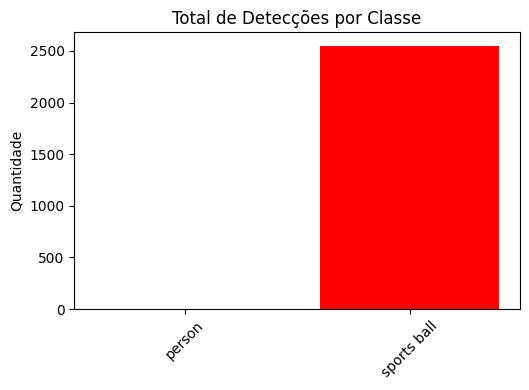

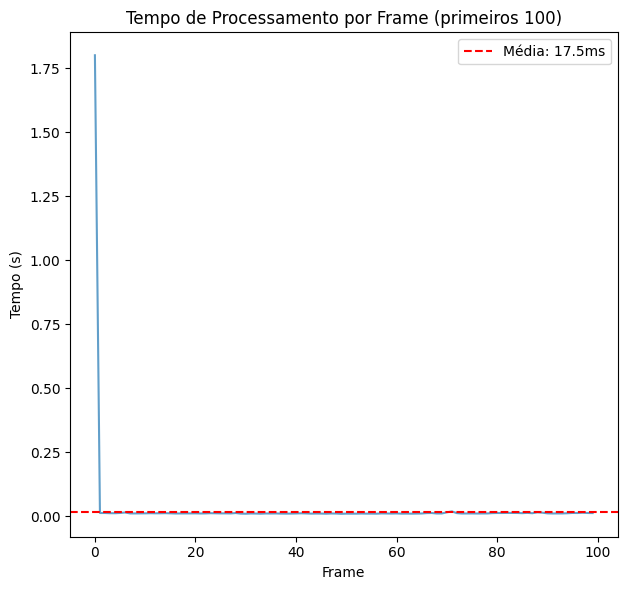

In [8]:
print("\n📈 Visualizando resultados...")

# Gráfico 1: Detecções por classe
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(detection_stats.keys(), detection_stats.values(), color=['green', 'red'])
plt.title('Total de Detecções por Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 2: Tempo de processamento por frame
plt.subplot(1, 2, 2)
plt.plot(frame_times[:100], alpha=0.7)  # Primeiros 100 frames
plt.title('Tempo de Processamento por Frame (primeiros 100)')
plt.xlabel('Frame')
plt.ylabel('Tempo (s)')
plt.axhline(y=np.mean(frame_times), color='r', linestyle='--', label=f'Média: {np.mean(frame_times)*1000:.1f}ms')
plt.legend()
plt.tight_layout()
plt.show()




============================================================
# SEÇÃO 8: EXIBIR FRAME DE EXEMPLO
============================================================


🖼️ Exibindo frame de exemplo...


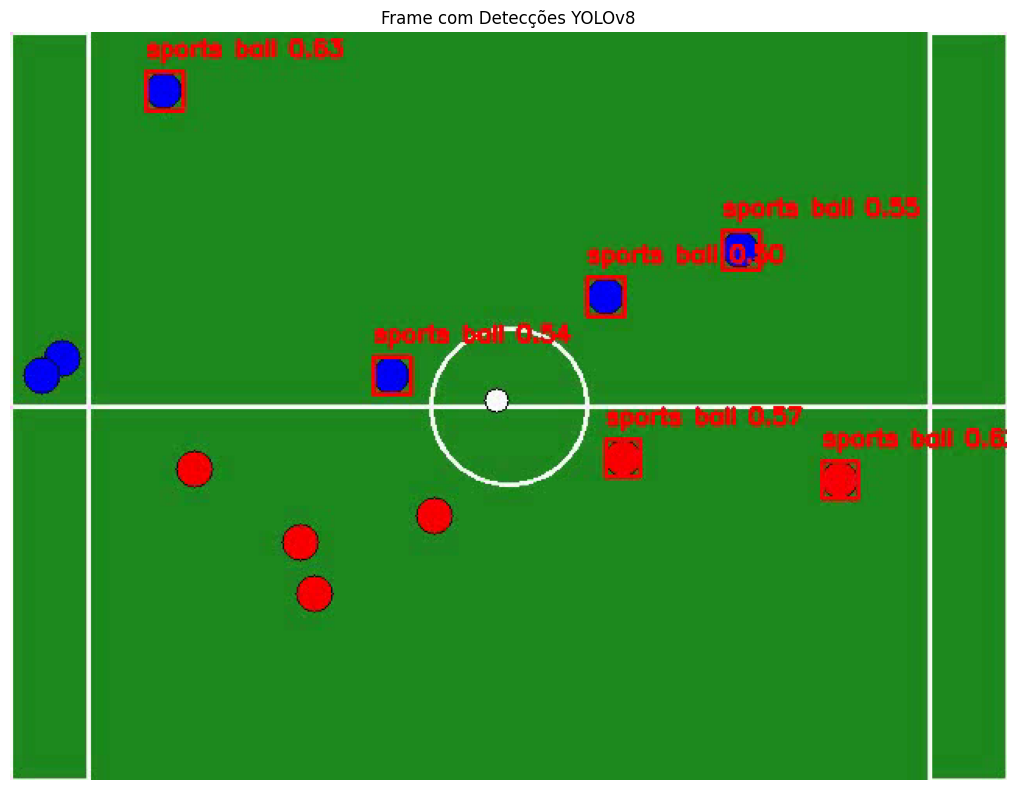

In [9]:

print("\n🖼️ Exibindo frame de exemplo...")

# Ler primeiro frame do vídeo processado
cap = cv2.VideoCapture(output_path)
ret, frame = cap.read()
cap.release()

if ret:
    # Converter BGR para RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.title('Frame com Detecções YOLOv8')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


============================================================
# SEÇÃO 9: DOWNLOAD DOS RESULTADOS
============================================================

In [10]:

print("\n💾 Download dos arquivos...")

from google.colab import files

# Oferecer download do vídeo processado
print("📹 Para baixar o vídeo processado:")
files.download(output_path)

# Salvar estatísticas em JSON
import json
stats = {
    'total_frames': total_frames,
    'processing_time': sum(frame_times),
    'avg_fps': total_frames / sum(frame_times),
    'detections': detection_stats
}

stats_path = "data/processed/detection_stats.json"
with open(stats_path, 'w') as f:
    json.dump(stats, f, indent=2)

print(f"📊 Estatísticas salvas em: {stats_path}")
files.download(stats_path)


💾 Download dos arquivos...
📹 Para baixar o vídeo processado:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📊 Estatísticas salvas em: data/processed/detection_stats.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ============================================================
# SEÇÃO 10: PRÓXIMOS PASSOS
============================================================

In [11]:

print("\n" + "=" * 60)
print("✅ TESTE CONCLUÍDO COM SUCESSO!")
print("=" * 60)
print("\n📋 Próximos passos:")
print("  1. Solicitar acesso ao SoccerTrack v2")
print("     🔗 https://soccertrack-dataset.github.io/")
print()
print("  2. Implementar tracking com ByteTrack")
print("     - Manter IDs consistentes dos jogadores")
print()
print("  3. Adicionar classificação de times por cor")
print("     - Separar time A, time B e árbitros")
print()
print("  4. Calcular métricas táticas")
print("     - Posse de bola")
print("     - Heatmaps de movimentação")
print("     - Velocidade dos jogadores")
print()
print("  5. Escrever artigo acadêmico")
print("     - Usar referências arXiv fornecidas")
print()
print("=" * 60)


✅ TESTE CONCLUÍDO COM SUCESSO!

📋 Próximos passos:
  1. Solicitar acesso ao SoccerTrack v2
     🔗 https://soccertrack-dataset.github.io/

  2. Implementar tracking com ByteTrack
     - Manter IDs consistentes dos jogadores

  3. Adicionar classificação de times por cor
     - Separar time A, time B e árbitros

  4. Calcular métricas táticas
     - Posse de bola
     - Heatmaps de movimentação
     - Velocidade dos jogadores

  5. Escrever artigo acadêmico
     - Usar referências arXiv fornecidas

